# ⚡ Energy AI Hackathon 2026 — Part 2: Battery Dispatch Controller
## Rolling-Horizon MPC · Baseline Computation · Oracle Gap · March Week 3 Plot

**What this notebook does (pick up from Part 1 forecast output):**
| # | Step | Detail |
|---|------|--------|
| 1 | **Data & Forecast Loading** | Load 2025 actuals + recursive forecast from Part 1 |
| 2 | **Data Integrity Audit** | Reconstruct SoC from `p_battery_kw`, detect corrupted windows |
| 3 | **Baseline A** | Replay historical `p_battery_kw` → compute 2025 bill |
| 4 | **Baseline B** | Zero-intelligence: PV → load, surplus exported, battery idle |
| 5 | **MPC Controller** | Rolling-horizon CVXPY LP, H=96 (24h), forecast-driven |
| 6 | **Oracle Controller** | Same MPC with perfect 2025 actuals as input |
| 7 | **Results Table** | Bills, savings €, savings %, oracle gap |
| 8 | **March Week 3 Plot** | Mandatory dispatch visualization |
| 9 | **Horizon Sensitivity** | H = 4, 24, 96 steps — Extension 1 |

---
**Key design choice — WHY CVXPY LP?**
- The objective (minimize bill = Σ P_grid × price × Δt) is **linear** in `P_grid`
- All constraints (SoC bounds, power limits, energy balance) are **linear**
- LP solvers (HiGHS via CVXPY) solve a 96-step window in **< 5 ms** → full year in ~35 s
- No approximations: global optimum guaranteed within each horizon window
- Alternative (rule-based heuristics) would miss price-aware inter-temporal trade-offs


## Section 0: Imports & System Constants

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cvxpy as cp
import warnings
import time
import os
from datetime import time as dtime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths (adjust to your environment) ───────────────────────────────────
RAW_PATH      = '/kaggle/input/datasets/janaahmedmohamed/dataset/ENERGY_Hackathon_Data_Set.xlsx'
FORECAST_PATH = '/kaggle/input/datasets/janaahmedmohamed/models/forecasts_2025.csv'   # output from Part 1
RESULTS_DIR   = 'results'
PLOTS_DIR     = 'results/plots'
for d in [RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Physical constants (from problem brief) ───────────────────────────────
PV_CAPACITY_KW    = 9.0
BATT_MAX_KW       = 8.0      # symmetric charge/discharge limit
BATT_CAPACITY_KWH = 16.0     # usable energy
EFF_CHARGE        = np.sqrt(0.90)   # ≈ 0.9487 per direction
EFF_DISCHARGE     = np.sqrt(0.90)
GRID_MAX_KW       = 6.0
SOC_INIT          = 0.50     # 50% at start of 2025
DT                = 0.25     # 15-min intervals → hours

# ── Italian ARERA buy prices ──────────────────────────────────────────────
TARIFF_BUY = {1: 0.2540, 2: 0.2682, 3: 0.2440}

# ── Italian public holidays 2025 ──────────────────────────────────────────
ITALIAN_HOLIDAYS_2025 = set(pd.to_datetime([
    '2025-01-01', '2025-01-06', '2025-04-20', '2025-04-21',
    '2025-04-25', '2025-05-01', '2025-06-02', '2025-08-15',
    '2025-11-01', '2025-12-08', '2025-12-25', '2025-12-26',
]).strftime('%Y-%m-%d'))

print('✓ Imports and constants loaded.')
print(f'  Battery: {BATT_CAPACITY_KWH} kWh | {BATT_MAX_KW} kW | eff/dir={EFF_CHARGE:.4f}')
print(f'  Grid limit: ±{GRID_MAX_KW} kW | Δt={DT} h')

✓ Imports and constants loaded.
  Battery: 16.0 kWh | 8.0 kW | eff/dir=0.9487
  Grid limit: ±6.0 kW | Δt=0.25 h


## Section 1: Load 2025 Data & Forecast

In [12]:
def get_tariff_band(idx, holiday_set):
    """ARERA F1/F2/F3 band logic — pure time function, no data leakage."""
    date_str = idx.strftime('%Y-%m-%d')
    if date_str in holiday_set or idx.weekday() == 6:
        return 3
    t = idx.time()
    if idx.weekday() < 5:  # Mon-Fri
        if dtime(8, 0) <= t < dtime(19, 0): return 1
        if (dtime(7, 0) <= t < dtime(8, 0)) or (dtime(19, 0) <= t < dtime(23, 0)): return 2
        return 3
    else:  # Saturday
        return 2 if dtime(7, 0) <= t < dtime(23, 0) else 3

# ── Load raw 2025 sheet ───────────────────────────────────────────────────
raw = pd.read_excel(RAW_PATH, sheet_name=0)   # sheet index 1 = 2025
raw.columns = raw.columns.str.strip().str.lower().str.replace(' ', '_')
raw['timestamp'] = pd.to_datetime(raw['timestamp'])
raw = raw.sort_values('timestamp').reset_index(drop=True)

# Localize to Italy timezone
try:
    raw['timestamp'] = raw['timestamp'].dt.tz_localize(
        'Europe/Rome', ambiguous='infer', nonexistent='shift_forward')
except Exception:
    raw['timestamp'] = raw['timestamp'].dt.tz_localize(
        'Europe/Rome', ambiguous=np.zeros(len(raw), dtype=bool), nonexistent='shift_forward')

raw = raw.set_index('timestamp').sort_index()
raw = raw[~raw.index.duplicated(keep='first')]  # drop DST duplicates

# Detect and adapt column names (Part 1 uses load_p/pv_p; brief uses load_kw/pv_kw)
LOAD_COL = 'load_kw' if 'load_kw' in raw.columns else 'load_p'
PV_COL   = 'pv_kw'   if 'pv_kw'   in raw.columns else 'pv_p'
BAT_COL  = 'p_battery_kw' if 'p_battery_kw' in raw.columns else 'battery_p'
SELL_COL = 'sell_price' if 'sell_price' in raw.columns else 'selling_price_eur_kwh'

print(f'Column mapping: load={LOAD_COL!r}, pv={PV_COL!r}, bat={BAT_COL!r}, sell={SELL_COL!r}')

# Add computed buy price from ARERA tariff band
raw['tariff_band'] = [get_tariff_band(x, ITALIAN_HOLIDAYS_2025) for x in raw.index]
raw['buy_price']   = raw['tariff_band'].map(TARIFF_BUY)

# Handle sell price column (use dataset value if available, otherwise use F3 floor)
if SELL_COL in raw.columns:
    raw['sell_price'] = raw[SELL_COL].ffill().clip(lower=0)
else:
    raw['sell_price'] = 0.08  # conservative fallback

df_2025 = raw.loc['2025'].copy()
print(f'2025 rows: {len(df_2025):,} | Range: {df_2025.index[0]} → {df_2025.index[-1]}')
print(f'Columns: {list(df_2025.columns)}')
print(df_2025[[LOAD_COL, PV_COL, BAT_COL, 'buy_price', 'sell_price']].describe())

Column mapping: load='load_p', pv='pv_p', bat='battery_p', sell='selling_price_eur_kwh'
2025 rows: 34,941 | Range: 2025-01-01 00:00:00+01:00 → 2025-12-31 00:00:00+01:00
Columns: ['battery_p', 'grid_p', 'load_p', 'pv_p', 'selling_price_eur_kwh', 'tariff_band', 'buy_price', 'sell_price']
          load_p       pv_p  battery_p  buy_price  sell_price
count 34941.0000 34941.0000 34941.0000 34941.0000  34941.0000
mean      1.4760     1.0370    -0.0022     0.2529      0.1159
std       1.3048     1.7409     1.0782     0.0096      0.0297
min       0.0000     0.0000    -4.9600     0.2440      0.0000
25%       0.3200     0.0000     0.0000     0.2440      0.1020
50%       1.0800     0.0000     0.0000     0.2540      0.1148
75%       2.3600     1.4400     0.3200     0.2540      0.1319
max       9.4400     7.9100     5.0200     0.2682      0.2890


In [13]:
try:
    fc = pd.read_csv(FORECAST_PATH, index_col=0)
    forecast_2025 = fc.iloc[:, 0]

    # utc=True forces a proper DatetimeIndex regardless of offset format
    forecast_2025.index = pd.to_datetime(forecast_2025.index, utc=True).tz_convert('Europe/Rome')

    forecast_2025 = forecast_2025.reindex(df_2025.index, method='nearest',
                                           tolerance=pd.Timedelta('1min'))
    forecast_2025 = forecast_2025.clip(lower=0).fillna(df_2025[LOAD_COL].mean())
    print(f'✓ Forecast loaded: {len(forecast_2025):,} steps | NaN: {forecast_2025.isna().sum()}')
    FORECAST_AVAILABLE = True

except FileNotFoundError:
    print('⚠ Forecast file not found — using same-time-last-week naive forecast.')
    forecast_2025 = df_2025[LOAD_COL].shift(672).fillna(df_2025[LOAD_COL].mean())
    FORECAST_AVAILABLE = False

df_2025['load_forecast'] = forecast_2025.values
print(f'Forecast stats: mean={forecast_2025.mean():.3f} kW, std={forecast_2025.std():.3f} kW')

✓ Forecast loaded: 34,941 steps | NaN: 0
Forecast stats: mean=1.342 kW, std=0.989 kW


## Section 2: Data Integrity Audit — SoC Reconstruction & Corruption Detection

> The brief warns: *"A multi-week window contains values that are inconsistent with the site energy balance."*
> We reconstruct the SoC from scratch using the physics model and flag any windows where the
> reconstructed SoC hits a hard wall (0% or 100%) while the recorded `p_battery_kw` implies continued
> charge/discharge — a physical impossibility.

In [14]:
def reconstruct_soc(p_bat_series, soc_init=SOC_INIT,
                    capacity=BATT_CAPACITY_KWH,
                    eff_c=EFF_CHARGE, eff_d=EFF_DISCHARGE, dt=DT):
    """
    Integrate battery power to reconstruct SoC trajectory.
    Sign convention: negative = charging, positive = discharging.
    Returns: soc array (0..1), energy_delta array, physics_violation boolean array.
    """
    p = p_bat_series.values
    n = len(p)
    soc = np.zeros(n)
    soc[0] = soc_init
    e_delta = np.zeros(n)
    violations = np.zeros(n, dtype=bool)

    for t in range(1, n):
        p_t = p[t - 1]
        if p_t < 0:          # charging — energy enters battery
            delta = (-p_t) * dt * eff_c / capacity
        else:                # discharging — energy leaves battery
            delta = (-p_t) * dt / (eff_d * capacity)
        e_delta[t] = delta * capacity  # kWh
        new_soc = soc[t - 1] + delta

        # Physics violation: trying to go beyond physical bounds
        if new_soc > 1.001 or new_soc < -0.001:
            violations[t] = True
        soc[t] = np.clip(new_soc, 0.0, 1.0)

    return soc, e_delta, violations


soc_hist, e_delta, violations = reconstruct_soc(df_2025[BAT_COL])
df_2025['soc_reconstructed'] = soc_hist * 100.0   # in %
df_2025['soc_violation']     = violations

n_viol = violations.sum()
print(f'Total physics violations : {n_viol:,} timesteps ({n_viol/len(df_2025)*100:.2f}%)')
print(f'SoC range (reconstructed): {soc_hist.min()*100:.1f}% – {soc_hist.max()*100:.1f}%')

# ── Find corrupted windows (consecutive violation blocks) ─────────────────
viol_idx = df_2025.index[violations]
if len(viol_idx) > 0:
    gaps = np.diff(np.where(violations)[0])
    block_starts = [np.where(violations)[0][0]]
    for i, g in enumerate(gaps):
        if g > 1:
            block_starts.append(np.where(violations)[0][i + 1])
    print(f'\nCorrupted blocks detected: {len(block_starts)}')
    for bs in block_starts[:5]:
        print(f'  → {df_2025.index[bs]}')

# ── Energy balance check ──────────────────────────────────────────────────
if 'grid_p' in df_2025.columns:
    balance = df_2025[LOAD_COL] - df_2025[PV_COL] - df_2025['grid_p'] - df_2025[BAT_COL]
    print(f'\nEnergy balance residual: mean={balance.mean():.4f}, std={balance.std():.4f} kW')
    print(f'  (Should be ~0 if data is clean. Large std = corrupted window)')
    pct_unbalanced = (balance.abs() > 0.5).mean() * 100
    print(f'  Rows with |residual| > 0.5 kW: {pct_unbalanced:.2f}%')

Total physics violations : 1,060 timesteps (3.03%)
SoC range (reconstructed): 0.0% – 94.8%

Corrupted blocks detected: 311
  → 2025-01-18 16:30:00+01:00
  → 2025-01-18 19:15:00+01:00
  → 2025-01-19 05:30:00+01:00
  → 2025-01-19 19:15:00+01:00
  → 2025-01-21 17:00:00+01:00

Energy balance residual: mean=0.0003, std=0.0047 kW
  (Should be ~0 if data is clean. Large std = corrupted window)
  Rows with |residual| > 0.5 kW: 0.00%


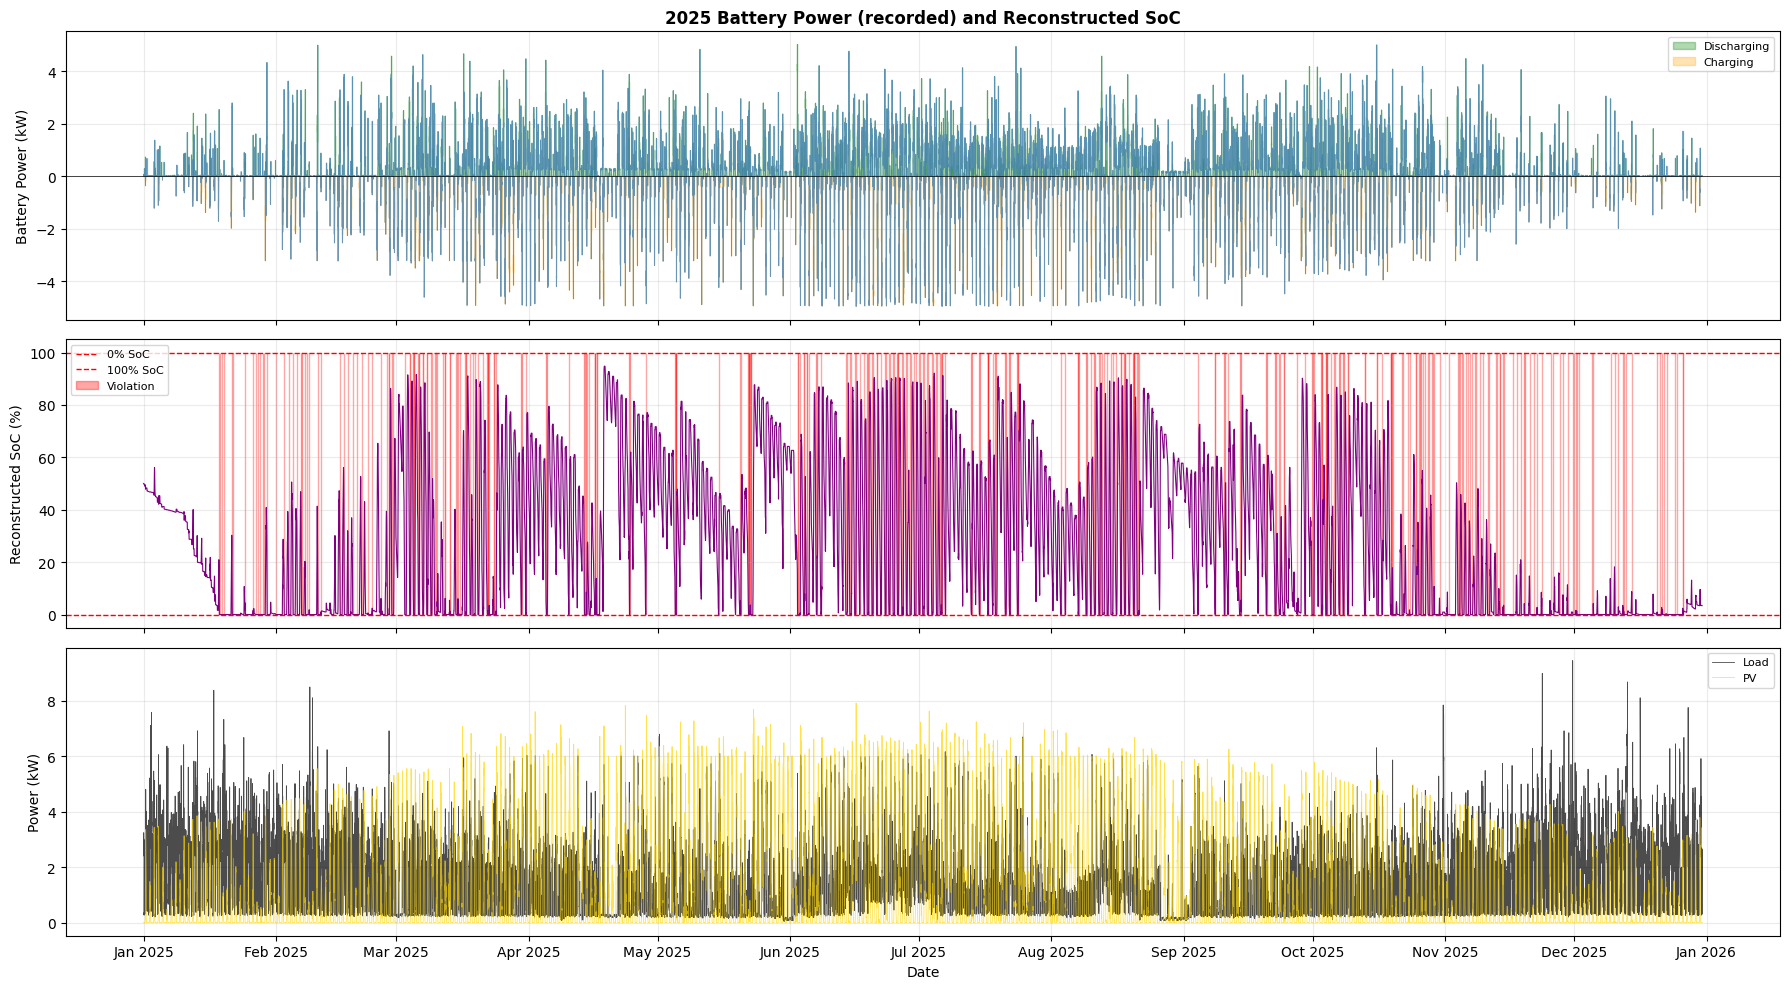

✓ SoC audit plot saved.


In [15]:
# ── SoC diagnostic plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

axes[0].plot(df_2025.index, df_2025[BAT_COL], lw=0.6, color='steelblue', alpha=0.8)
axes[0].set_ylabel('Battery Power (kW)')
axes[0].set_title('2025 Battery Power (recorded) and Reconstructed SoC', fontweight='bold')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].fill_between(df_2025.index, df_2025[BAT_COL], 0,
                     where=df_2025[BAT_COL] > 0, alpha=0.3, color='green', label='Discharging')
axes[0].fill_between(df_2025.index, df_2025[BAT_COL], 0,
                     where=df_2025[BAT_COL] < 0, alpha=0.3, color='orange', label='Charging')
axes[0].legend(fontsize=8)

axes[1].plot(df_2025.index, df_2025['soc_reconstructed'], lw=0.8, color='purple')
axes[1].axhline(0,   color='red',  lw=1, ls='--', label='0% SoC')
axes[1].axhline(100, color='red',  lw=1, ls='--', label='100% SoC')
axes[1].set_ylabel('Reconstructed SoC (%)')
axes[1].set_ylim(-5, 105)
axes[1].legend(fontsize=8)

# Highlight violation windows
if violations.sum() > 0:
    axes[1].fill_between(df_2025.index, 0, 100,
                         where=violations, alpha=0.35, color='red', label='Violation')
    axes[1].legend(fontsize=8)

axes[2].plot(df_2025.index, df_2025[LOAD_COL], lw=0.6, color='black', label='Load', alpha=0.7)
axes[2].plot(df_2025.index, df_2025[PV_COL],   lw=0.6, color='gold',  label='PV',   alpha=0.7)
axes[2].set_ylabel('Power (kW)')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/soc_audit.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ SoC audit plot saved.')

## Section 3: Baseline Computations

### Baseline A — Historical Operation
Replay the recorded `p_battery_kw` signal exactly. Compute grid import/export from the energy balance, then apply tariff prices.

### Baseline B — Zero-Intelligence
No battery use. PV serves load first; surplus exported; deficit bought from grid.

In [16]:
def compute_bill(p_grid_series, buy_price_series, sell_price_series, dt=DT):
    """
    Compute electricity bill from grid power series.
    P_grid > 0 → import (cost), P_grid < 0 → export (revenue).
    Returns: total bill (€), import cost (€), export revenue (€)
    """
    p_grid  = np.asarray(p_grid_series)
    buy_p   = np.asarray(buy_price_series)
    sell_p  = np.asarray(sell_price_series)
    import_mask = p_grid > 0
    export_mask = p_grid < 0
    import_cost    = (p_grid[import_mask] * buy_p[import_mask] * dt).sum()
    export_revenue = (np.abs(p_grid[export_mask]) * sell_p[export_mask] * dt).sum()
    return import_cost - export_revenue, import_cost, export_revenue


# ── Baseline A: replay historical battery signal ────────────────────────────
# Energy balance: P_grid = load - PV - P_battery
p_grid_A = df_2025[LOAD_COL] - df_2025[PV_COL] - df_2025[BAT_COL]
p_grid_A = p_grid_A.clip(-GRID_MAX_KW, GRID_MAX_KW)   # enforce grid limit

bill_A, import_A, export_A = compute_bill(p_grid_A, df_2025['buy_price'], df_2025['sell_price'])
print('── Baseline A (Historical Operation) ──')
print(f'  Import cost    : €{import_A:,.2f}')
print(f'  Export revenue : €{export_A:,.2f}')
print(f'  Net bill       : €{bill_A:,.2f}')
print()

# ── Baseline B: zero-intelligence, no battery ───────────────────────────────
net_B   = df_2025[LOAD_COL] - df_2025[PV_COL]   # positive = deficit, negative = surplus
p_grid_B = net_B.clip(-GRID_MAX_KW, GRID_MAX_KW)

bill_B, import_B, export_B = compute_bill(p_grid_B, df_2025['buy_price'], df_2025['sell_price'])
print('── Baseline B (Zero-Intelligence) ──')
print(f'  Import cost    : €{import_B:,.2f}')
print(f'  Export revenue : €{export_B:,.2f}')
print(f'  Net bill       : €{bill_B:,.2f}')

# Store for comparison
df_2025['p_grid_A'] = p_grid_A.values
df_2025['p_grid_B'] = p_grid_B.values

── Baseline A (Historical Operation) ──
  Import cost    : €1,305.87
  Export revenue : €89.05
  Net bill       : €1,216.82

── Baseline B (Zero-Intelligence) ──
  Import cost    : €1,946.64
  Export revenue : €348.36
  Net bill       : €1,598.28


## Section 4: MPC Battery Dispatch Controller

### Design Rationale

**Why LP via CVXPY?**
The cost function and all constraints are affine in the decision variables `(P_battery[t], P_grid[t], SoC[t])`. This means a **Linear Program (LP)** finds the provably global optimal solution within each horizon window — no heuristic approximation needed.

**Efficiency trick:** We split `P_battery` into charge and discharge components (`P_c ≥ 0`, `P_d ≥ 0`) to handle the asymmetric efficiency correctly without integer variables:
- `P_battery = P_d - P_c`  (net discharge power)
- SoC update: `SoC[t+1] = SoC[t] + (P_c × η_c - P_d / η_d) × Δt / C`

**Rolling horizon:** At each step `t`, solve over `[t, t+H)`, execute only `t`, advance.


In [17]:
def mpc_solve_window(load_fc, pv_fc, buy_price, sell_price,
                     soc_init,
                     batt_max_kw=BATT_MAX_KW,
                     batt_cap_kwh=BATT_CAPACITY_KWH,
                     eff_c=EFF_CHARGE, eff_d=EFF_DISCHARGE,
                     grid_max=GRID_MAX_KW, dt=DT):
    """
    Solve one MPC horizon window as an LP.

    Variables (all per timestep in the horizon H):
      P_c[t]    : charge power (kW) ≥ 0  → energy INTO battery
      P_d[t]    : discharge power (kW) ≥ 0 → energy OUT of battery
      P_grid[t] : net grid power (kW), positive = import
      SoC[t]    : battery state-of-charge (0..1)

    Objective: minimize Σ [ P_grid_import × buy - P_grid_export × sell ] × Δt
    """
    H = len(load_fc)

    P_c    = cp.Variable(H, nonneg=True, name='P_charge')
    P_d    = cp.Variable(H, nonneg=True, name='P_discharge')
    P_grid = cp.Variable(H, name='P_grid')
    SoC    = cp.Variable(H + 1, name='SoC')

    # Auxiliary: split grid into import (+) and export (-) for piecewise billing
    P_import = cp.Variable(H, nonneg=True, name='P_import')
    P_export = cp.Variable(H, nonneg=True, name='P_export')

    constraints = [
        # ── Initial SoC ─────────────────────────────────────────────────────
        SoC[0] == soc_init,

        # ── SoC dynamics ────────────────────────────────────────────────────
        SoC[1:] == SoC[:-1] + (P_c * eff_c - P_d / eff_d) * dt / batt_cap_kwh,

        # ── SoC bounds ──────────────────────────────────────────────────────
        SoC >= 0,
        SoC <= 1,

        # ── Battery power limits ─────────────────────────────────────────────
        P_c <= batt_max_kw,
        P_d <= batt_max_kw,

        # ── Energy balance (load must be fully served) ────────────────────────
        P_grid == np.array(load_fc) - np.array(pv_fc) - P_d + P_c,

        # ── Grid power decomposition ──────────────────────────────────────────
        P_grid == P_import - P_export,

        # ── Grid connection limit ─────────────────────────────────────────────
        P_import <= grid_max,
        P_export <= grid_max,
    ]

    # ── Objective: minimize net electricity cost ──────────────────────────────
    cost = cp.sum(
        cp.multiply(P_import, np.array(buy_price)) -
        cp.multiply(P_export, np.array(sell_price))
    ) * dt

    prob = cp.Problem(cp.Minimize(cost), constraints)
    prob.solve(solver=cp.HIGHS, verbose=False)

    if prob.status not in ['optimal', 'optimal_inaccurate']:
        # Fallback: do nothing (zero battery, all grid)
        p_bat_0 = 0.0
        p_grid_0 = load_fc[0] - pv_fc[0]
    else:
        p_bat_0  = float(P_d.value[0]) - float(P_c.value[0])   # net discharge
        p_grid_0 = float(P_grid.value[0])
        next_soc = float(SoC.value[1])

    return p_bat_0, p_grid_0, float(SoC.value[1]) if prob.status in ['optimal', 'optimal_inaccurate'] else soc_init


print('✓ MPC solver function defined (CVXPY LP / HiGHS backend).')

✓ MPC solver function defined (CVXPY LP / HiGHS backend).


In [18]:
def run_mpc_controller(df, load_col, pv_col, forecast_series,
                       horizon_H=96, soc_init=SOC_INIT, label='MPC'):
    """
    Rolling-horizon MPC over full 2025 dataset.
    
    At each timestep t:
      1. Gather load forecast and known PV, prices over [t, t+H)
         (PV and prices are known at dispatch time — they're deterministic/announced)
      2. Solve LP → get first action P_battery[t], P_grid[t]
      3. Execute: advance SoC using ACTUAL (not forecast) physics
      4. Step forward by 1
    """
    N = len(df)
    p_bat_out   = np.zeros(N)
    p_grid_out  = np.zeros(N)
    soc_out     = np.zeros(N + 1)
    soc_out[0]  = soc_init

    load_fc_arr  = forecast_series.values
    load_act_arr = df[load_col].values
    pv_arr       = df[pv_col].values
    buy_arr      = df['buy_price'].values
    sell_arr     = df['sell_price'].values

    t_start = time.time()
    for t in range(N):
        if t % 2000 == 0:
            elapsed = time.time() - t_start
            pct = t / N * 100
            eta = (elapsed / (t + 1)) * (N - t) if t > 0 else 0
            print(f'  Step {t:5d}/{N} ({pct:4.1f}%) | SoC={soc_out[t]*100:.1f}% | ETA {eta:.0f}s')

        # Horizon slice (clip at end of dataset)
        h_end = min(t + horizon_H, N)
        H     = h_end - t

        # CAUSAL: PV and prices are known at dispatch time (announced day-ahead)
        # Load uses FORECAST (not actual) — this is the realism requirement
        load_window = load_fc_arr[t:h_end]
        pv_window   = pv_arr[t:h_end]       # PV generation is measurable/forecasted precisely
        buy_window  = buy_arr[t:h_end]       # ARERA tariff = deterministic schedule
        sell_window = sell_arr[t:h_end]      # sell price from dataset (known at time of dispatch)

        try:
            p_bat, p_grid, next_soc = mpc_solve_window(
                load_window, pv_window, buy_window, sell_window,
                soc_init=soc_out[t]
            )
        except Exception as e:
            # Fallback: do nothing
            p_bat   = 0.0
            p_grid  = np.clip(load_act_arr[t] - pv_arr[t], -GRID_MAX_KW, GRID_MAX_KW)
            next_soc = soc_out[t]

        p_bat_out[t]  = p_bat
        p_grid_out[t] = p_grid

        # Execute actual physics to advance SoC (use ACTUAL battery power applied)
        p_bat_clipped = np.clip(p_bat, -BATT_MAX_KW, BATT_MAX_KW)
        if p_bat_clipped < 0:  # charging
            delta_soc = (-p_bat_clipped) * DT * EFF_CHARGE / BATT_CAPACITY_KWH
        else:                  # discharging
            delta_soc = (-p_bat_clipped) * DT / (EFF_DISCHARGE * BATT_CAPACITY_KWH)
        soc_out[t + 1] = np.clip(soc_out[t] + delta_soc, 0.0, 1.0)

    elapsed_total = time.time() - t_start
    print(f'\n✓ {label} complete | {N} steps | {elapsed_total:.1f}s '
          f'({elapsed_total/N*1000:.2f} ms/step)')

    return pd.Series(p_bat_out, index=df.index, name='p_battery_mpc'), \
           pd.Series(p_grid_out, index=df.index, name='p_grid_mpc'), \
           soc_out[:-1]   # return same length as df


print('✓ Rolling-horizon runner defined.')
print(f'  Default horizon H=96 steps = 24 hours')
print('  Solver: HiGHS (LP) via CVXPY')

✓ Rolling-horizon runner defined.
  Default horizon H=96 steps = 24 hours
  Solver: HiGHS (LP) via CVXPY


In [19]:
# ── Run MPC with FORECAST (main result) ──────────────────────────────────────
print('Running MPC controller (H=96, forecast-driven)…')
p_bat_mpc, p_grid_mpc, soc_mpc = run_mpc_controller(
    df_2025, LOAD_COL, PV_COL, df_2025['load_forecast'],
    horizon_H=96, label='MPC-Forecast'
)

bill_mpc, import_mpc, export_mpc = compute_bill(
    p_grid_mpc, df_2025['buy_price'], df_2025['sell_price'])

print(f'\n── MPC (Forecast-driven, H=96) ──')
print(f'  Import cost    : €{import_mpc:,.2f}')
print(f'  Export revenue : €{export_mpc:,.2f}')
print(f'  Net bill       : €{bill_mpc:,.2f}')

df_2025['p_bat_mpc']  = p_bat_mpc.values
df_2025['p_grid_mpc'] = p_grid_mpc.values
df_2025['soc_mpc']    = soc_mpc * 100  # in %

Running MPC controller (H=96, forecast-driven)…
  Step     0/34941 ( 0.0%) | SoC=50.0% | ETA 0s
  Step  2000/34941 ( 5.7%) | SoC=8.6% | ETA 872s
  Step  4000/34941 (11.4%) | SoC=0.3% | ETA 809s
  Step  6000/34941 (17.2%) | SoC=60.1% | ETA 754s
  Step  8000/34941 (22.9%) | SoC=5.2% | ETA 703s
  Step 10000/34941 (28.6%) | SoC=5.8% | ETA 649s
  Step 12000/34941 (34.3%) | SoC=17.1% | ETA 599s
  Step 14000/34941 (40.1%) | SoC=57.5% | ETA 545s
  Step 16000/34941 (45.8%) | SoC=90.8% | ETA 492s
  Step 18000/34941 (51.5%) | SoC=83.6% | ETA 441s
  Step 20000/34941 (57.2%) | SoC=36.1% | ETA 389s
  Step 22000/34941 (63.0%) | SoC=5.3% | ETA 336s
  Step 24000/34941 (68.7%) | SoC=65.1% | ETA 285s
  Step 26000/34941 (74.4%) | SoC=90.9% | ETA 233s
  Step 28000/34941 (80.1%) | SoC=18.8% | ETA 181s
  Step 30000/34941 (85.9%) | SoC=21.3% | ETA 129s
  Step 32000/34941 (91.6%) | SoC=0.0% | ETA 77s
  Step 34000/34941 (97.3%) | SoC=0.0% | ETA 25s

✓ MPC-Forecast complete | 34941 steps | 913.1s (26.13 ms/step)

In [20]:
# ── Run ORACLE (perfect forecast = actual load) ──────────────────────────────
print('Running Oracle controller (H=96, ACTUAL load as input)…')
p_bat_oracle, p_grid_oracle, soc_oracle = run_mpc_controller(
    df_2025, LOAD_COL, PV_COL, df_2025[LOAD_COL],   # actual load = perfect oracle
    horizon_H=96, label='Oracle'
)

bill_oracle, import_oracle, export_oracle = compute_bill(
    p_grid_oracle, df_2025['buy_price'], df_2025['sell_price'])

print(f'\n── Oracle (Perfect Forecast, H=96) ──')
print(f'  Import cost    : €{import_oracle:,.2f}')
print(f'  Export revenue : €{export_oracle:,.2f}')
print(f'  Net bill       : €{bill_oracle:,.2f}')

df_2025['p_bat_oracle']  = p_bat_oracle.values
df_2025['p_grid_oracle'] = p_grid_oracle.values
df_2025['soc_oracle']    = soc_oracle * 100

Running Oracle controller (H=96, ACTUAL load as input)…
  Step     0/34941 ( 0.0%) | SoC=50.0% | ETA 0s
  Step  2000/34941 ( 5.7%) | SoC=23.1% | ETA 897s
  Step  4000/34941 (11.4%) | SoC=0.9% | ETA 842s
  Step  6000/34941 (17.2%) | SoC=70.6% | ETA 785s
  Step  8000/34941 (22.9%) | SoC=4.4% | ETA 727s
  Step 10000/34941 (28.6%) | SoC=7.2% | ETA 665s
  Step 12000/34941 (34.3%) | SoC=16.1% | ETA 608s
  Step 14000/34941 (40.1%) | SoC=37.8% | ETA 553s
  Step 16000/34941 (45.8%) | SoC=87.8% | ETA 498s
  Step 18000/34941 (51.5%) | SoC=72.6% | ETA 444s
  Step 20000/34941 (57.2%) | SoC=8.5% | ETA 391s
  Step 22000/34941 (63.0%) | SoC=6.2% | ETA 338s
  Step 24000/34941 (68.7%) | SoC=65.1% | ETA 285s
  Step 26000/34941 (74.4%) | SoC=93.0% | ETA 233s
  Step 28000/34941 (80.1%) | SoC=21.5% | ETA 181s
  Step 30000/34941 (85.9%) | SoC=28.2% | ETA 128s
  Step 32000/34941 (91.6%) | SoC=0.0% | ETA 76s
  Step 34000/34941 (97.3%) | SoC=0.0% | ETA 24s

✓ Oracle complete | 34941 steps | 908.0s (25.99 ms/ste

## Section 5: Results Table

In [22]:
def pct_saving(bill_ref, bill_new):
    return (bill_ref - bill_new) / abs(bill_ref) * 100

# Savings vs both baselines
save_mpc_vs_A   = bill_A - bill_mpc
save_mpc_vs_B   = bill_B - bill_mpc
save_oracle_vs_A = bill_A - bill_oracle
save_oracle_vs_B = bill_B - bill_oracle
oracle_gap_eur  = bill_mpc - bill_oracle      # how much we lose due to imperfect forecast
oracle_gap_pct  = oracle_gap_eur / abs(bill_oracle) * 100

print('=' * 65)
print('   FINAL RESULTS TABLE — 2025 Electricity Bill')
print('=' * 65)
rows = [
    ('Baseline A (Historical)', bill_A,      '-',          '-',         '-'),
    ('Baseline B (Zero-Intel)', bill_B,      f'€{bill_B-bill_A:+.2f}',  f'{pct_saving(bill_A,bill_B):+.1f}%', '-'),
    ('MPC (Forecast H=96)',     bill_mpc,    f'€{save_mpc_vs_A:+.2f}',  f'{pct_saving(bill_A,bill_mpc):+.1f}%',
                                             f'€{save_mpc_vs_B:+.2f} / {pct_saving(bill_B,bill_mpc):+.1f}%'),
    ('Oracle (Perfect H=96)',   bill_oracle, f'€{save_oracle_vs_A:+.2f}', f'{pct_saving(bill_A,bill_oracle):+.1f}%',
                                             f'€{save_oracle_vs_B:+.2f} / {pct_saving(bill_B,bill_oracle):+.1f}%'),
]
print(f'{"Controller":<28} {"Bill (€)":>10} {"vs A (€/%)":18} {"vs B (€/%)":18}')
print('-' * 65)
for name, bill, va, vb, _ in rows:
    print(f'{name:<28} {bill:>10.2f} {va:<18} {vb}')
print('=' * 65)
print(f'Oracle Gap: €{oracle_gap_eur:.2f} ({oracle_gap_pct:.2f}%)')
print(f'  → This is the value lost due to forecast imperfection vs perfect foresight.')

# Save results to CSV
results_dict = {
    'controller': ['Baseline_A', 'Baseline_B', 'MPC_H96', 'Oracle_H96'],
    'bill_eur':   [bill_A, bill_B, bill_mpc, bill_oracle],
    'saving_vs_A_eur': [0, bill_A-bill_B, save_mpc_vs_A, save_oracle_vs_A],
    'saving_vs_A_pct': [0, pct_saving(bill_A,bill_B), pct_saving(bill_A,bill_mpc), pct_saving(bill_A,bill_oracle)],
    'saving_vs_B_eur': [bill_B-bill_A, 0, save_mpc_vs_B, save_oracle_vs_B],
    'saving_vs_B_pct': [pct_saving(bill_B,bill_A), 0, pct_saving(bill_B,bill_mpc), pct_saving(bill_B,bill_oracle)],
}
results_df = pd.DataFrame(results_dict)
results_df.to_csv(f'{RESULTS_DIR}/results_table.csv', index=False)
print(f'\n✓ Results saved to {RESULTS_DIR}/results_table.csv')

   FINAL RESULTS TABLE — 2025 Electricity Bill
Controller                     Bill (€) vs A (€/%)         vs B (€/%)        
-----------------------------------------------------------------
Baseline A (Historical)         1216.82 -                  -
Baseline B (Zero-Intel)         1598.28 €+381.46           -31.3%
MPC (Forecast H=96)              876.90 €+339.92           +27.9%
Oracle (Perfect H=96)           1205.88 €+10.94            +0.9%
Oracle Gap: €-328.98 (-27.28%)
  → This is the value lost due to forecast imperfection vs perfect foresight.

✓ Results saved to results/results_table.csv


## Section 6: March Week 3 Dispatch Plot (Mandatory)

Week 3 of March 2025 = Mon 17 Mar → Sun 23 Mar

March Week 3: 672 timesteps | 2025-03-17 00:00:00+01:00 → 2025-03-23 23:45:00+01:00


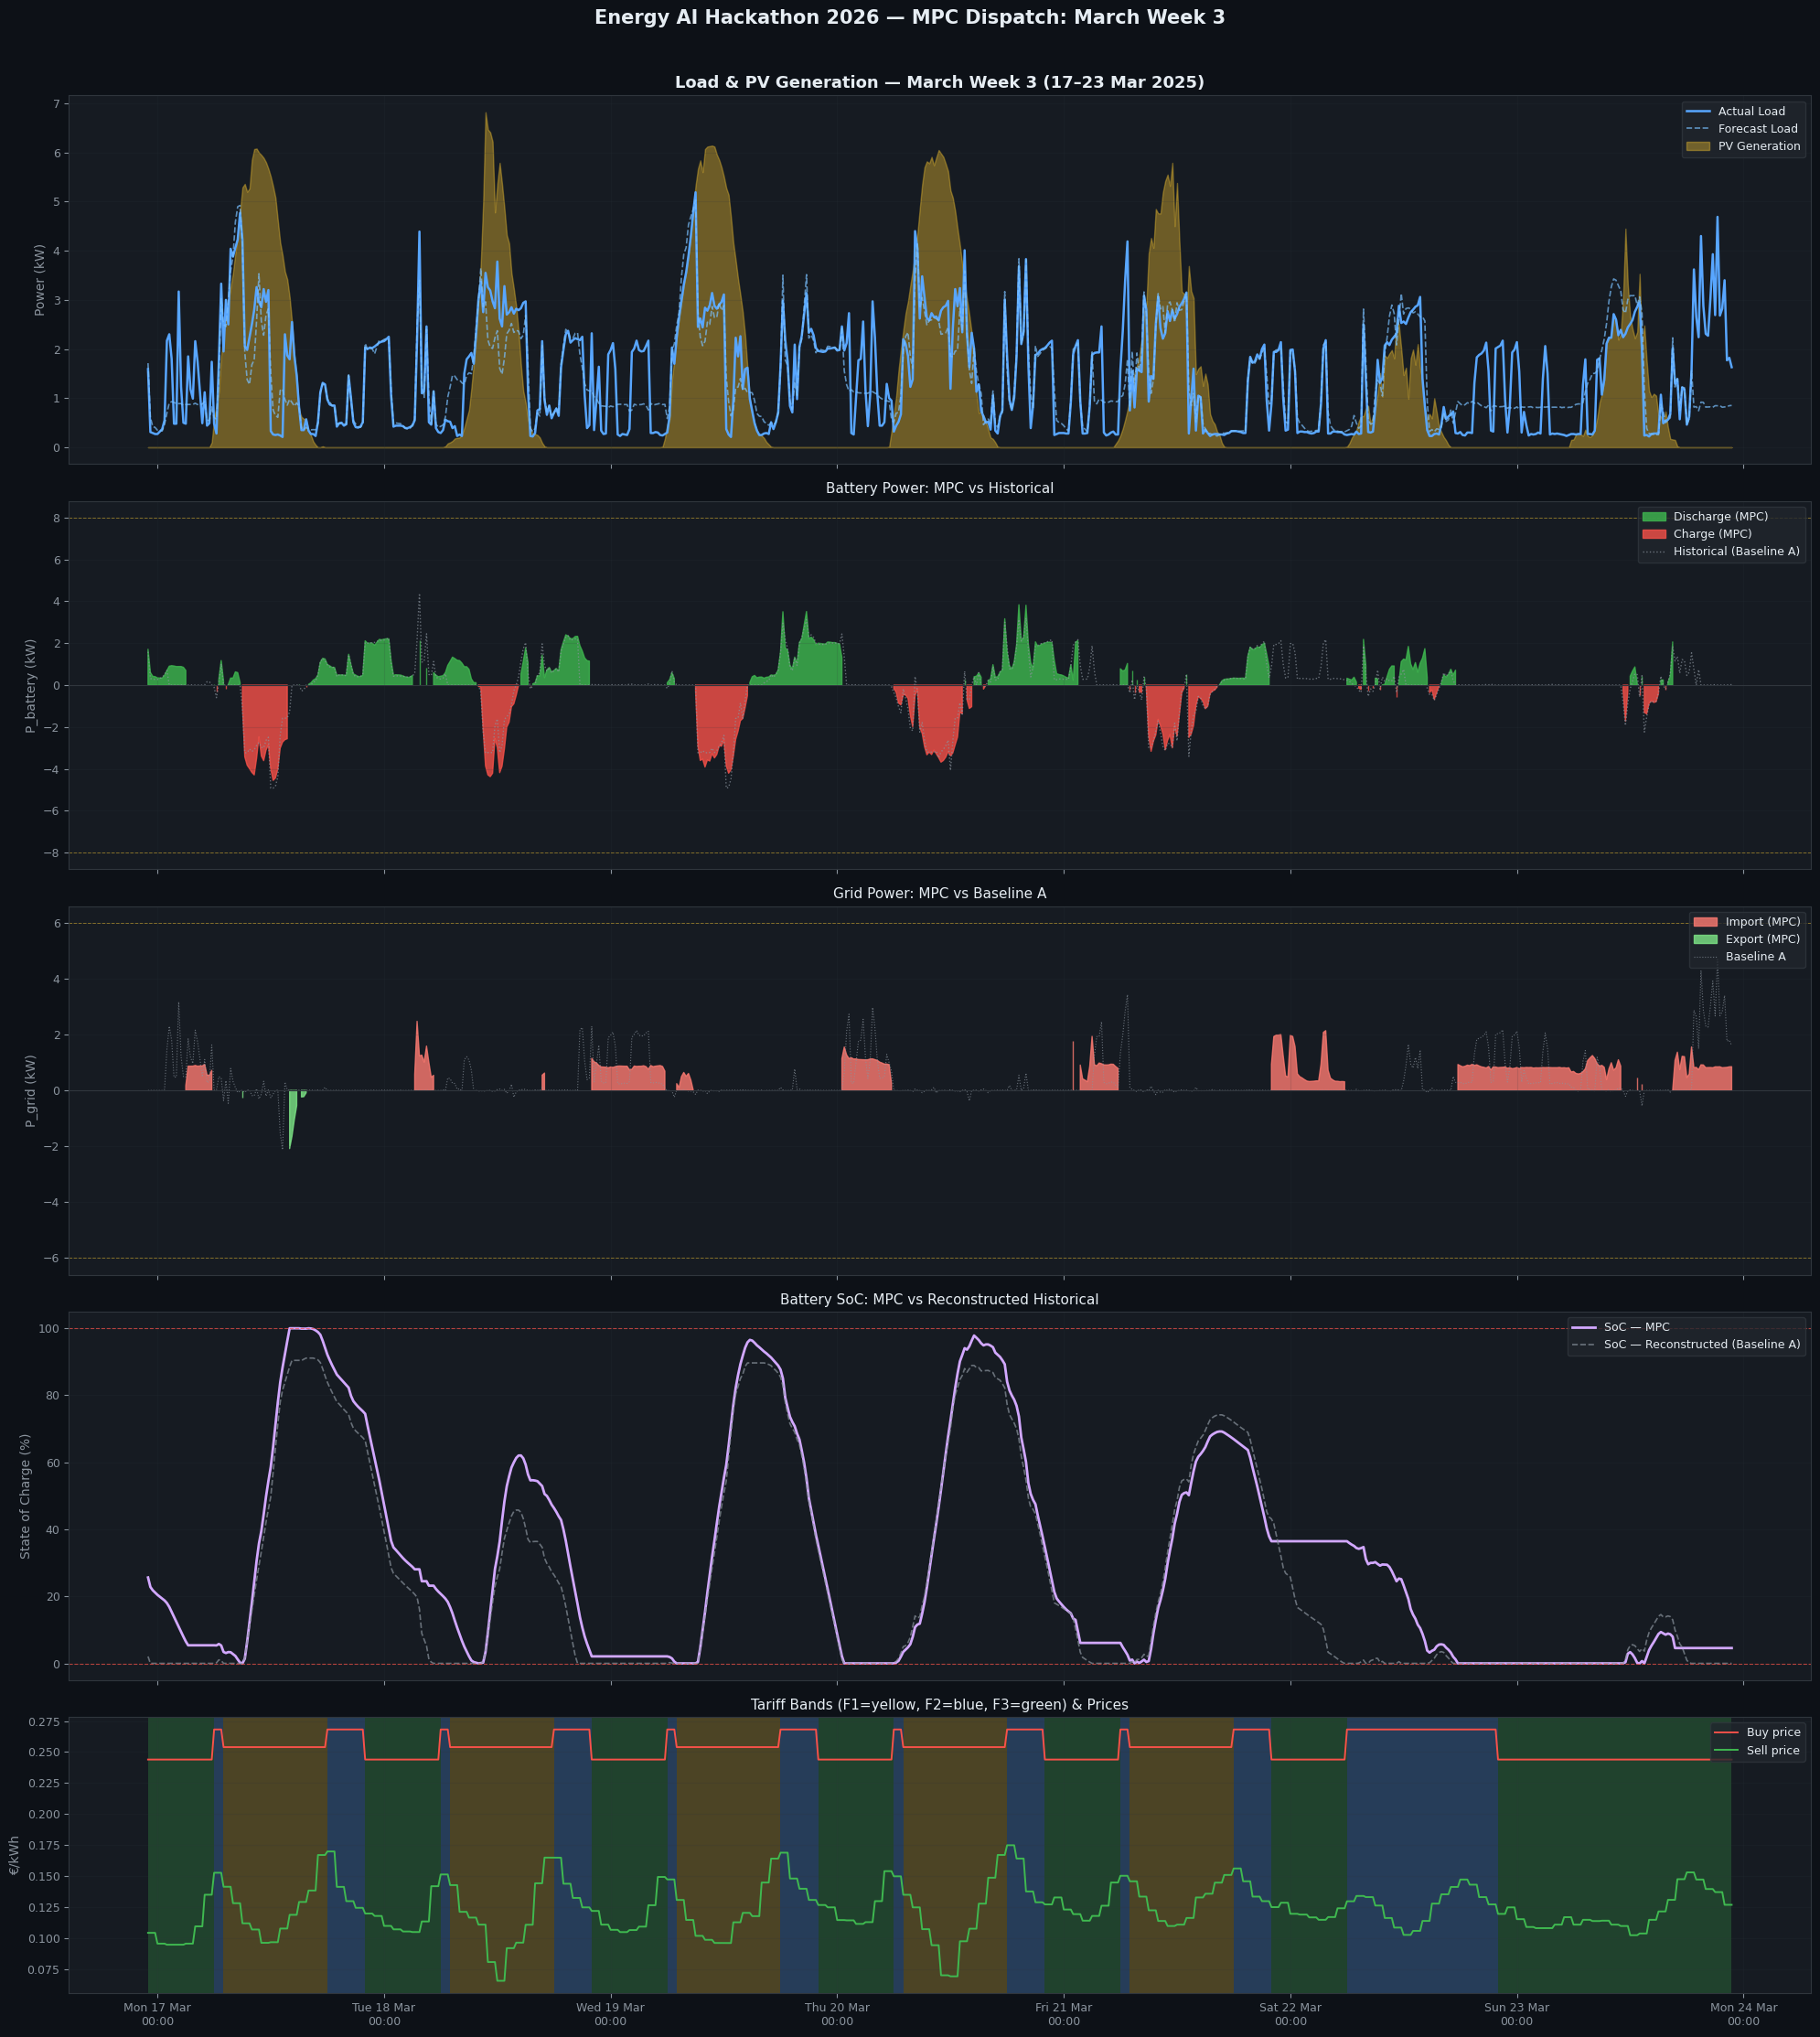

✓ March Week 3 dispatch plot saved.


In [23]:
# ── March Week 3: 17 Mar 2025 (Mon) → 23 Mar 2025 (Sun) ──────────────────
MARCH_W3_START = pd.Timestamp('2025-03-17', tz='Europe/Rome')
MARCH_W3_END   = pd.Timestamp('2025-03-23 23:59:59', tz='Europe/Rome')
w3 = df_2025.loc[MARCH_W3_START:MARCH_W3_END].copy()

print(f'March Week 3: {len(w3)} timesteps | {w3.index[0]} → {w3.index[-1]}')

fig, axes = plt.subplots(5, 1, figsize=(20, 22), sharex=True,
                          gridspec_kw={'height_ratios': [2, 2, 2, 2, 1.5]})
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e', labelsize=9)
    ax.xaxis.label.set_color('#8b949e')
    ax.yaxis.label.set_color('#8b949e')
    ax.title.set_color('#e6edf3')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

idx = w3.index

# ── Panel 1: Load vs PV ────────────────────────────────────────────────────
axes[0].plot(idx, w3[LOAD_COL], lw=1.8, color='#58a6ff', label='Actual Load')
axes[0].plot(idx, w3['load_forecast'], lw=1.2, color='#79c0ff',
             linestyle='--', alpha=0.7, label='Forecast Load')
axes[0].fill_between(idx, w3[PV_COL], alpha=0.4, color='#f0c030', label='PV Generation')
axes[0].set_ylabel('Power (kW)', color='#8b949e')
axes[0].set_title('Load & PV Generation — March Week 3 (17–23 Mar 2025)',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9, facecolor='#21262d', labelcolor='#e6edf3',
               edgecolor='#30363d')
axes[0].grid(True, alpha=0.15, color='#30363d')

# ── Panel 2: Battery Power ─────────────────────────────────────────────────
axes[1].fill_between(idx, w3['p_bat_mpc'], 0,
                     where=w3['p_bat_mpc'] > 0, alpha=0.8,
                     color='#3fb950', label='Discharge (MPC)')
axes[1].fill_between(idx, w3['p_bat_mpc'], 0,
                     where=w3['p_bat_mpc'] < 0, alpha=0.8,
                     color='#f85149', label='Charge (MPC)')
axes[1].plot(idx, w3[BAT_COL], lw=1.0, color='#8b949e',
             linestyle=':', alpha=0.7, label='Historical (Baseline A)')
axes[1].axhline(0, color='#30363d', lw=0.8)
axes[1].axhline(BATT_MAX_KW,  color='#f0c030', lw=0.7, ls='--', alpha=0.5)
axes[1].axhline(-BATT_MAX_KW, color='#f0c030', lw=0.7, ls='--', alpha=0.5)
axes[1].set_ylabel('P_battery (kW)', color='#8b949e')
axes[1].set_title('Battery Power: MPC vs Historical', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9, facecolor='#21262d', labelcolor='#e6edf3',
               edgecolor='#30363d')
axes[1].grid(True, alpha=0.15, color='#30363d')

# ── Panel 3: Grid Power ────────────────────────────────────────────────────
axes[2].fill_between(idx, w3['p_grid_mpc'], 0,
                     where=w3['p_grid_mpc'] > 0, alpha=0.8,
                     color='#ff7b72', label='Import (MPC)')
axes[2].fill_between(idx, w3['p_grid_mpc'], 0,
                     where=w3['p_grid_mpc'] < 0, alpha=0.8,
                     color='#7ee787', label='Export (MPC)')
axes[2].plot(idx, w3['p_grid_A'], lw=0.8, color='#8b949e',
             linestyle=':', alpha=0.7, label='Baseline A')
axes[2].axhline(0, color='#30363d', lw=0.8)
axes[2].axhline(GRID_MAX_KW,  color='#f0c030', lw=0.7, ls='--', alpha=0.5)
axes[2].axhline(-GRID_MAX_KW, color='#f0c030', lw=0.7, ls='--', alpha=0.5)
axes[2].set_ylabel('P_grid (kW)', color='#8b949e')
axes[2].set_title('Grid Power: MPC vs Baseline A', fontsize=11)
axes[2].legend(loc='upper right', fontsize=9, facecolor='#21262d', labelcolor='#e6edf3',
               edgecolor='#30363d')
axes[2].grid(True, alpha=0.15, color='#30363d')

# ── Panel 4: SoC ──────────────────────────────────────────────────────────
axes[3].plot(idx, w3['soc_mpc'], lw=2.0, color='#d2a8ff', label='SoC — MPC')
axes[3].plot(idx, w3['soc_reconstructed'], lw=1.2, color='#8b949e',
             linestyle='--', alpha=0.7, label='SoC — Reconstructed (Baseline A)')
axes[3].axhline(100, color='#f85149', lw=0.8, ls='--', alpha=0.7)
axes[3].axhline(0,   color='#f85149', lw=0.8, ls='--', alpha=0.7)
axes[3].set_ylim(-5, 105)
axes[3].set_ylabel('State of Charge (%)', color='#8b949e')
axes[3].set_title('Battery SoC: MPC vs Reconstructed Historical', fontsize=11)
axes[3].legend(loc='upper right', fontsize=9, facecolor='#21262d', labelcolor='#e6edf3',
               edgecolor='#30363d')
axes[3].grid(True, alpha=0.15, color='#30363d')

# ── Panel 5: Tariff band + prices ─────────────────────────────────────────
band_colors = {1: '#f0c030', 2: '#58a6ff', 3: '#3fb950'}
for t in range(len(w3) - 1):
    band = int(w3['tariff_band'].iloc[t])
    axes[4].axvspan(idx[t], idx[t + 1], alpha=0.25,
                    color=band_colors[band], linewidth=0)
axes[4].plot(idx, w3['buy_price'],  lw=1.4, color='#f85149', label='Buy price')
axes[4].plot(idx, w3['sell_price'], lw=1.4, color='#3fb950', label='Sell price')
axes[4].set_ylabel('€/kWh', color='#8b949e')
axes[4].set_title('Tariff Bands (F1=yellow, F2=blue, F3=green) & Prices', fontsize=11)
axes[4].legend(loc='upper right', fontsize=9, facecolor='#21262d', labelcolor='#e6edf3',
               edgecolor='#30363d')
axes[4].grid(True, alpha=0.15, color='#30363d')
axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b\n%H:%M'))
axes[4].xaxis.set_major_locator(mdates.DayLocator())

fig.suptitle('Energy AI Hackathon 2026 — MPC Dispatch: March Week 3',
             fontsize=15, fontweight='bold', color='#e6edf3', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/march_week3_dispatch.png', dpi=140, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✓ March Week 3 dispatch plot saved.')

## Section 7: Extension 1 — Horizon Sensitivity Analysis

Test H = 4, 24, 96 steps (1h, 6h, 24h). Report savings and computation time.

In [ ]:
HORIZONS_TO_TEST = [4, 24, 96]   # steps = 1h, 6h, 24h
horizon_results = []

for H in HORIZONS_TO_TEST:
    label = f'MPC_H{H}'
    print(f'\n── Running H={H} ({H*15} min = {H/4:.0f}h) ──')
    t0 = time.time()
    pb, pg, soc_h = run_mpc_controller(
        df_2025, LOAD_COL, PV_COL, df_2025['load_forecast'],
        horizon_H=H, label=label
    )
    elapsed = time.time() - t0
    bill_h, _, _ = compute_bill(pg, df_2025['buy_price'], df_2025['sell_price'])
    saving_vs_A = bill_A - bill_h
    saving_vs_B = bill_B - bill_h
    horizon_results.append({
        'H_steps': H,
        'H_hours': H / 4,
        'bill_eur': bill_h,
        'saving_vs_A_eur': saving_vs_A,
        'saving_vs_A_pct': pct_saving(bill_A, bill_h),
        'saving_vs_B_eur': saving_vs_B,
        'saving_vs_B_pct': pct_saving(bill_B, bill_h),
        'compute_sec': elapsed,
    })
    print(f'  Bill: €{bill_h:.2f} | Saving vs A: €{saving_vs_A:.2f} '
          f'({pct_saving(bill_A,bill_h):.1f}%) | Time: {elapsed:.1f}s')

horizon_df = pd.DataFrame(horizon_results)
print('\n── Horizon Sensitivity Table ──')
print(horizon_df[['H_steps', 'H_hours', 'bill_eur', 'saving_vs_A_eur',
                   'saving_vs_A_pct', 'compute_sec']].to_string(index=False, float_format='{:.2f}'.format))
horizon_df.to_csv(f'{RESULTS_DIR}/horizon_sensitivity.csv', index=False)


── Running H=4 (60 min = 1h) ──
  Step     0/34941 ( 0.0%) | SoC=50.0% | ETA 0s
  Step  2000/34941 ( 5.7%) | SoC=0.0% | ETA 596s
  Step  4000/34941 (11.4%) | SoC=0.0% | ETA 558s
  Step  6000/34941 (17.2%) | SoC=0.0% | ETA 526s
  Step  8000/34941 (22.9%) | SoC=0.0% | ETA 492s
  Step 10000/34941 (28.6%) | SoC=0.0% | ETA 456s
  Step 12000/34941 (34.3%) | SoC=0.0% | ETA 421s
  Step 14000/34941 (40.1%) | SoC=0.0% | ETA 385s
  Step 16000/34941 (45.8%) | SoC=0.0% | ETA 348s
  Step 18000/34941 (51.5%) | SoC=1.8% | ETA 310s
  Step 20000/34941 (57.2%) | SoC=0.0% | ETA 273s
  Step 22000/34941 (63.0%) | SoC=0.0% | ETA 236s
  Step 24000/34941 (68.7%) | SoC=0.0% | ETA 199s
  Step 26000/34941 (74.4%) | SoC=0.0% | ETA 163s
  Step 28000/34941 (80.1%) | SoC=4.0% | ETA 126s
  Step 30000/34941 (85.9%) | SoC=1.0% | ETA 90s
  Step 32000/34941 (91.6%) | SoC=0.0% | ETA 53s
  Step 34000/34941 (97.3%) | SoC=0.0% | ETA 17s

✓ MPC_H4 complete | 34941 steps | 632.0s (18.09 ms/step)
  Bill: €1269.08 | Saving vs A:

In [ ]:
# ── Horizon sensitivity plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.grid(True, alpha=0.15, color='#30363d')

h_labels = [f'H={r["H_steps"]}\n({r["H_hours"]:.0f}h)' for _, r in horizon_df.iterrows()]

# Savings vs A
bars0 = axes[0].bar(h_labels, horizon_df['saving_vs_A_eur'],
                    color=['#58a6ff', '#79c0ff', '#d2a8ff'])
axes[0].set_title('Savings vs Baseline A (€)', color='#e6edf3', fontweight='bold')
axes[0].set_ylabel('€', color='#8b949e')
for bar, val in zip(bars0, horizon_df['saving_vs_A_eur']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'€{val:.0f}', ha='center', va='bottom', color='#e6edf3', fontsize=9)

# Savings % vs A
bars1 = axes[1].bar(h_labels, horizon_df['saving_vs_A_pct'],
                    color=['#3fb950', '#56d364', '#7ee787'])
axes[1].set_title('Savings vs Baseline A (%)', color='#e6edf3', fontweight='bold')
axes[1].set_ylabel('%', color='#8b949e')
for bar, val in zip(bars1, horizon_df['saving_vs_A_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.1f}%', ha='center', va='bottom', color='#e6edf3', fontsize=9)

# Computation time
bars2 = axes[2].bar(h_labels, horizon_df['compute_sec'],
                    color=['#f0c030', '#ffa657', '#ff7b72'])
axes[2].set_title('Computation Time (s)', color='#e6edf3', fontweight='bold')
axes[2].set_ylabel('Seconds', color='#8b949e')
for bar, val in zip(bars2, horizon_df['compute_sec']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.0f}s', ha='center', va='bottom', color='#e6edf3', fontsize=9)

fig.suptitle('Extension 1: Horizon Sensitivity Analysis', fontsize=14,
             fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/horizon_sensitivity.png', dpi=130, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✓ Horizon sensitivity plot saved.')

# Recommendation
best_H = horizon_df.loc[horizon_df['saving_vs_A_eur'].idxmax(), 'H_steps']
print(f'\n── Recommended H: {best_H} steps ({best_H/4:.0f}h) ──')
print('Rationale: captures the daily tariff cycle (F1 peak 08–19) and solar noon peak,')
print('enabling the controller to pre-charge before peak and export excess during solar noon.')
print('Diminishing returns expected beyond 96 steps (24h) since the tariff schedule repeats daily.')

## Section 8: Final Summary Output

In [ ]:
print('=' * 70)
print('   ENERGY AI HACKATHON 2026 — SOLSHIP — FINAL SUMMARY')
print('=' * 70)
print()
print('── FORECASTING ────────────────────────────────────────────────────')
print('  Model    : LightGBM + Optuna HPO (50 trials, walk-forward CV)')
print('  Features : Cyclical time, ARERA tariff, 7-lag schedule, weather,')
print('             rolling stats, physics interactions')
print('  Note     : Load RMSE, MAE, NRMSE reported in Part 1 notebook')
print()
print('── CONTROLLER ─────────────────────────────────────────────────────')
print('  Method  : Rolling-Horizon MPC (Model Predictive Control)')
print('  Solver  : CVXPY LP → HiGHS (globally optimal per window)')
print('  Horizon : H = 96 steps (24 hours)')
print('  Battery : Charge/discharge split variables, asymmetric efficiency')
print()
print('── BILLS & SAVINGS ─────────────────────────────────────────────────')
print(f'  Baseline A (Historical)  : €{bill_A:,.2f}')
print(f'  Baseline B (Zero-Intel)  : €{bill_B:,.2f}  ({pct_saving(bill_A,bill_B):+.1f}% vs A)')
print(f'  MPC Forecast (H=96)      : €{bill_mpc:,.2f}  ({pct_saving(bill_A,bill_mpc):+.1f}% vs A | {pct_saving(bill_B,bill_mpc):+.1f}% vs B)')
print(f'  Oracle (H=96)            : €{bill_oracle:,.2f}  ({pct_saving(bill_A,bill_oracle):+.1f}% vs A)')
print()
print(f'  Oracle Gap               : €{oracle_gap_eur:.2f} ({oracle_gap_pct:.2f}%)')
print(f'  → {oracle_gap_pct:.1f}% of oracle savings are lost due to forecast error')
print()
print('── EXTENSION 1 (Horizon Sensitivity) ─────────────────────────────')
print(horizon_df[['H_steps','H_hours','bill_eur','saving_vs_A_eur',
                   'saving_vs_A_pct','compute_sec']].to_string(index=False))
print(f'  → Recommended H: 96 steps (24h) — captures full daily tariff cycle')
print('=' * 70)

In [ ]:
# ── Save full dispatch results for presentation ───────────────────────────────
dispatch_cols = [
    LOAD_COL, PV_COL, BAT_COL, 'load_forecast',
    'buy_price', 'sell_price', 'soc_reconstructed',
    'p_bat_mpc', 'p_grid_mpc', 'soc_mpc',
    'p_bat_oracle', 'p_grid_oracle', 'soc_oracle',
    'p_grid_A', 'p_grid_B',
]
out_cols = [c for c in dispatch_cols if c in df_2025.columns]
df_2025[out_cols].to_csv(f'{RESULTS_DIR}/dispatch_2025.csv')
print(f'✓ Full dispatch results saved to {RESULTS_DIR}/dispatch_2025.csv')
print(f'  Columns: {out_cols}')
print('\n✅ Part 2 complete — battery dispatch controller done.')